# Chapter 19. Random variables and distributions

## Discrete distributions

### The Bernoulli distribution

In [13]:
from scipy.stats import bernoulli

In [12]:
[bernoulli.rvs(p=0.5) for _ in range(10)]    # ten Bernoulli(0.5)-distributed random numbers 

[1, 1, 1, 0, 1, 1, 1, 0, 1, 1]

This code demonstrates how to generate multiple random samples from a Bernoulli distribution using a list comprehension. The expression creates a list containing 10 independent samples, where each sample is drawn from a Bernoulli distribution with probability parameter `p=0.5`.

The `bernoulli.rvs(p=0.5)` call generates a single random variate (sample) from the Bernoulli distribution. With `p=0.5`, this means each sample has a 50% chance of being 1 (success) and a 50% chance of being 0 (failure) - essentially simulating a fair coin flip. The `rvs` method stands for "random variates" and is the standard method in scipy.stats for generating random samples from probability distributions.

The list comprehension `[... for _ in range(10)]` repeats this sampling process 10 times. The underscore `_` is a Python convention indicating that we don't actually need to use the loop variable - we're just iterating 10 times to collect 10 independent samples. This approach is more concise and Pythonic than writing an explicit for loop with an empty list that gets appended to.

The result will be a list of 10 binary values (0s and 1s), such as `[1, 0, 1, 1, 0, 0, 1, 0, 1, 0]`. Each run will produce different results due to the randomness, but on average, about half the values should be 1s and half should be 0s, reflecting the 50% probability parameter. This pattern is commonly used in statistics and machine learning for generating synthetic datasets or simulating random experiments.

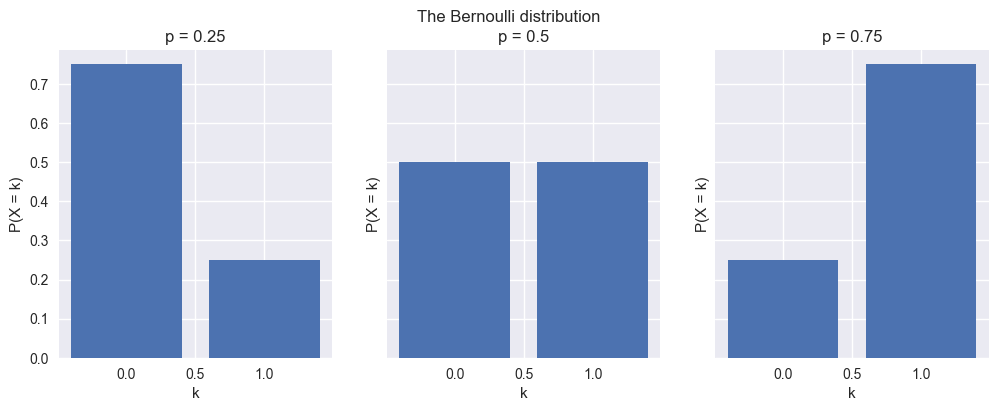

In [14]:
import matplotlib.pyplot as plt

params = [0.25, 0.5, 0.75]


with plt.style.context("seaborn-v0_8"):
    # Create subplots, one for each parameter, sharing the y-axis, 
    # fig is the Figure object and axs is an array of Axes objects
    fig, axs = plt.subplots(1, len(params), figsize=(4*len(params), 4), sharey=True)
    
    fig.suptitle("The Bernoulli distribution")
    for ax, p in zip(axs, params):
        x = range(2) # Possible outcomes for a Bernoulli trial
        y = [bernoulli.pmf(k=k, p=p) for k in x] # Probability mass function for each outcome
        ax.bar(x, y)
        ax.set_title(f"p = {p}")
        ax.set_ylabel("P(X = k)")
        ax.set_xlabel("k")  
    plt.show()

### The binomial distribution

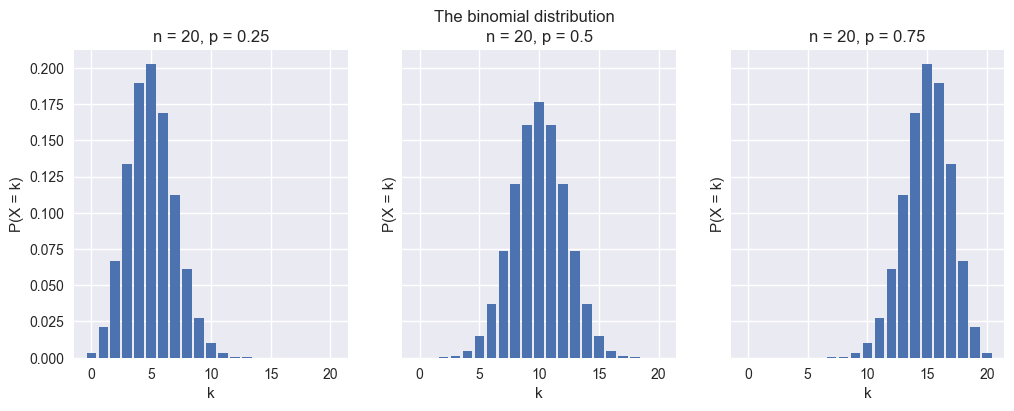

In [4]:
from scipy.stats.distributions import binom


params = [(20, 0.25), (20, 0.5), (20, 0.75)]


with plt.style.context("seaborn-v0_8"):
    fig, axs = plt.subplots(1, len(params), figsize=(4*len(params), 4), sharey=True)
    fig.suptitle("The binomial distribution")
    for ax, (n, p) in zip(axs, params):
        x = range(n+1)
        y = [binom.pmf(n=n, p=p, k=k) for k in x]
        ax.bar(x, y)
        ax.set_title(f"n = {n}, p = {p}")
        ax.set_ylabel("P(X = k)")
        ax.set_xlabel("k")    

    plt.show()

### The geometric distribution

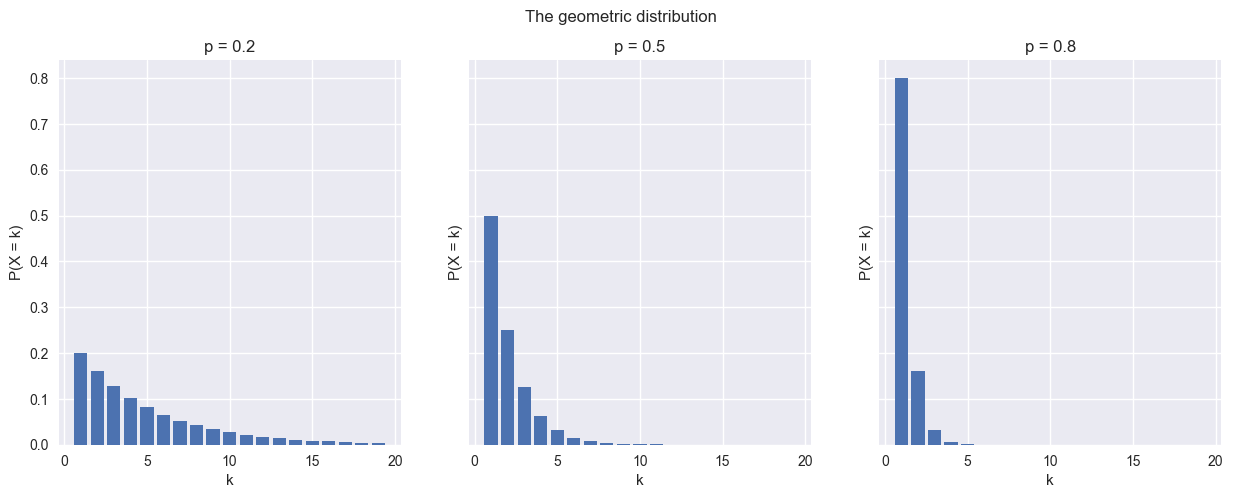

In [5]:
from scipy.stats import geom


params = [0.2, 0.5, 0.8]


with plt.style.context("seaborn-v0_8"):
    fig, axs = plt.subplots(1, len(params), figsize=(5*len(params), 5), sharey=True)
    fig.suptitle("The geometric distribution")
    for ax, p in zip(axs, params):
        x = range(1, 20)
        y = [geom.pmf(p=p, k=k) for k in x]
        ax.bar(x, y)
        ax.set_title(f"p = {p}")
        ax.set_ylabel("P(X = k)")
        ax.set_xlabel("k")

    plt.show()

### The uniform distribution

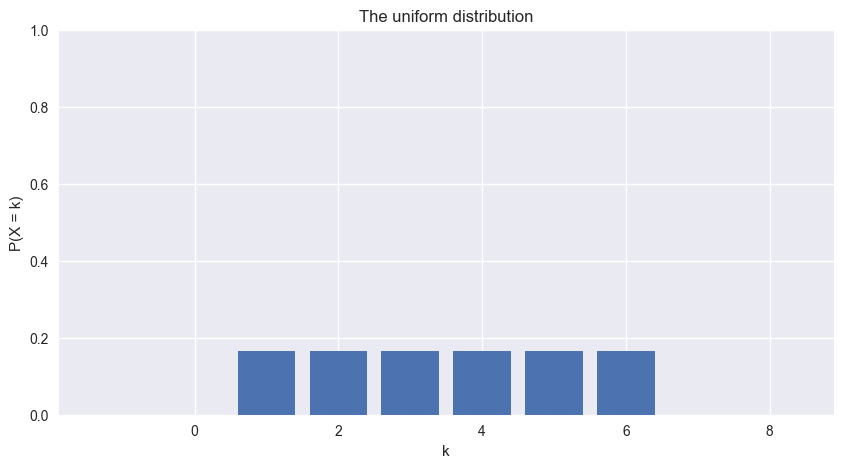

In [6]:
from scipy.stats import randint


with plt.style.context("seaborn-v0_8"):
    fig = plt.figure(figsize=(10, 5))
    plt.title("The uniform distribution")

    x = range(-1, 9)
    y = [randint.pmf(k=k, low=1, high=7) for k in x]
    plt.bar(x, y)
    plt.ylim(0, 1)
    plt.ylabel("P(X = k)")
    plt.xlabel("k")

    plt.show()

### Sums of discrete random variables

/Users/papagian/opt/anaconda3/envs/Elements310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/papagian/opt/anaconda3/envs/Elements310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


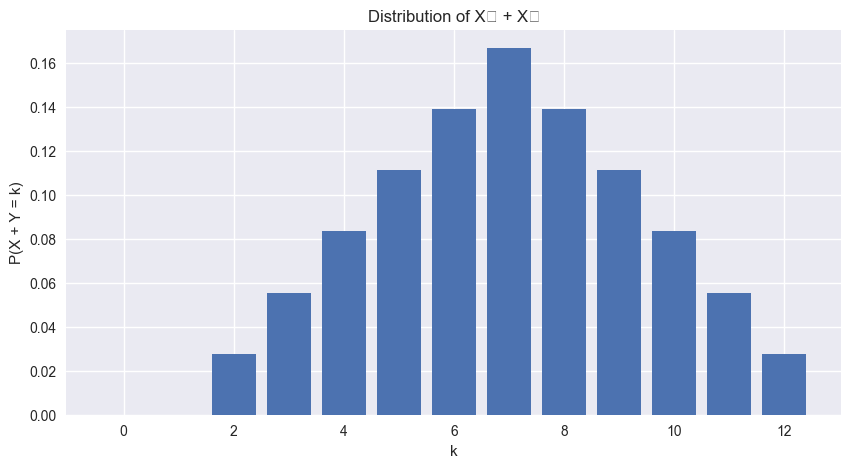

In [7]:
import numpy as np


dist_1 = [0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6]
dist_2 = [0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6]
sum_dist = np.convolve(dist_1, dist_1)


with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(10, 5))
    plt.bar(range(0, len(sum_dist)), sum_dist)
    plt.title("Distribution of X₁ + X₂")
    plt.ylabel("P(X + Y = k)")
    plt.xlabel("k")
    plt.show()

## Real-valued distributions

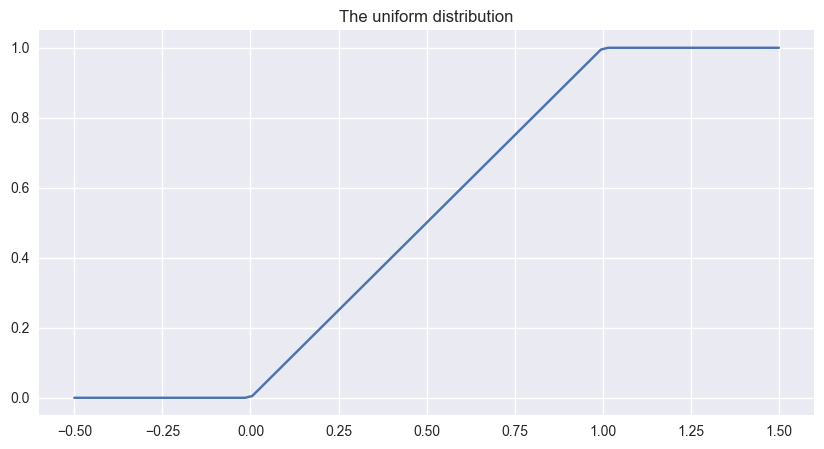

In [8]:
from scipy.stats import uniform
X = np.linspace(-0.5, 1.5, 100)
y = uniform.cdf(X)


with plt.style.context('seaborn-v0_8'):
    plt.figure(figsize=(10, 5))
    plt.title("The uniform distribution")
    plt.plot(X, y)
    plt.show()

### The exponential distribution

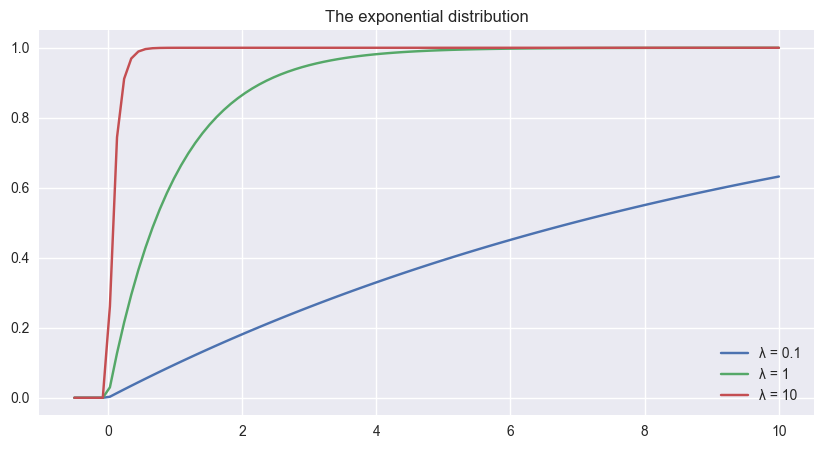

In [9]:
from scipy.stats import expon
X = np.linspace(-0.5, 10, 100)
params = [0.1, 1, 10]
ys = [expon.cdf(X, scale=1/l) for l in params]


with plt.style.context('seaborn-v0_8'):
    plt.figure(figsize=(10, 5))
    
    for l, y in zip(params, ys):
        plt.plot(X, y, label=f"λ = {l}")
    
    plt.title("The exponential distribution")
    plt.legend()
    plt.show()

### The normal distribution

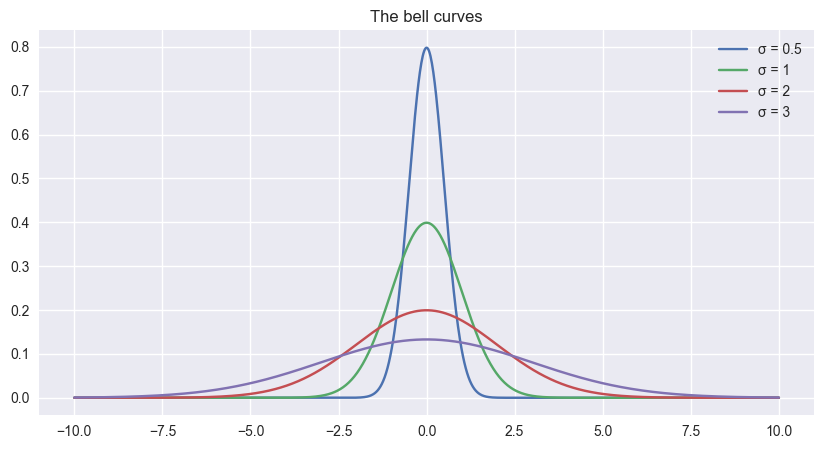

In [10]:
from scipy.stats import norm
X = np.linspace(-10, 10, 1000)
σs = [0.5, 1, 2, 3]
ys = [norm.pdf(X, scale=σ) for σ in σs]


with plt.style.context('seaborn-v0_8'):
    plt.figure(figsize=(10, 5))
    
    for σ, y in zip(σs, ys):
        plt.plot(X, y, label=f"σ = {σ}")
    
    plt.title("The bell curves")
    plt.legend()
    plt.show()

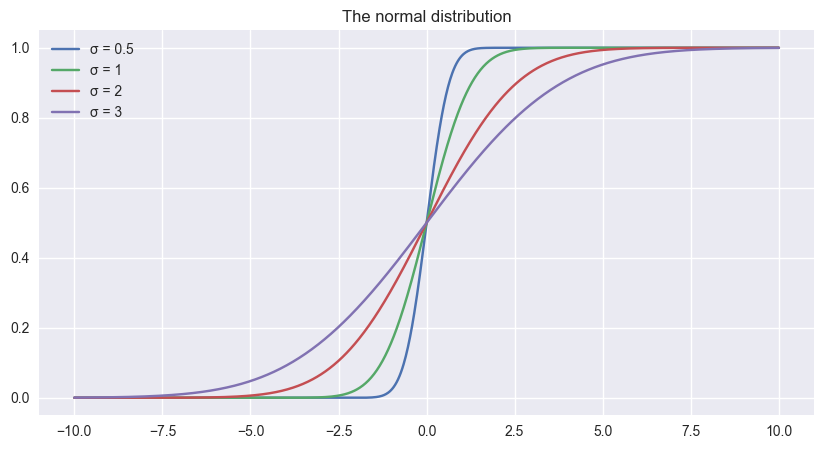

In [11]:
X = np.linspace(-10, 10, 1000)
σs = [0.5, 1, 2, 3]
ys = [norm.cdf(X, scale=σ) for σ in σs]


with plt.style.context('seaborn-v0_8'):
    plt.figure(figsize=(10, 5))
    
    for σ, y in zip(σs, ys):
        plt.plot(X, y, label=f"σ = {σ}")
    
    plt.title("The normal distribution")
    plt.legend()

    plt.show()